<a href="https://colab.research.google.com/github/ameydbharambe/BurnSightAI/blob/main/BurnClassifierRESNET50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Extract Dataset**

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="lShgzRpJB2fEcwXgE1HC")
project = rf.workspace("first-aid-vfyay").project("first-aid-app-2fa7k")
version = project.version(4)
dataset = version.download("folder")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to first-aid-app-4 in folder:: 100%|██████████| 3245/3245 [00:00<00:00, 5473.44it/s]


# **Import Necessary Libraries**

In [ ]:
# Standard libraries
import os
import random
import time
from pathlib import Path

# Numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Image processing
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Torchvision
from torchvision import transforms, datasets, models



# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Progress bars
from tqdm import tqdm

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# **Load Datasets**

In [ ]:
#Load path to split data (80-10-10)
train_dir = "/content/first-aid-app-4/train"
valid_dir = "/content/first-aid-app-4/valid"
test_dir = "/content/first-aid-app-4/test"

#Define parameters for transformation
size = 224
meanImageNet = [0.485, 0.456, 0.406]
stdImageNet = [0.229, 0.224, 0.225]

#Apply transformation on train, validation, and test data to ensure proper size for pretrained models
train_transform = transforms.Compose([
    # Resize randomly for training to learn variation
    transforms.RandomResizedCrop(
    size,
    scale=(0.8, 1.0)),

    # Data augmentation (Allows model to learn more diverse options)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    # Convert image from PIL format to PyTorch tensor
    transforms.ToTensor(),

    # Normalize using ImageNet statistics
    transforms.Normalize(
        mean=meanImageNet,
        std=stdImageNet
    )
])

# Validation/Test transformations
test_transform = transforms.Compose([
    # Resize to model input size
    transforms.Resize((size, size)),

    # Convert image to tensor
    transforms.ToTensor(),

    # Normalize using ImageNet statistics
    transforms.Normalize(
        mean=meanImageNet,
        std=stdImageNet
    )
])

#Create datasets using directory and ImageFolder assigns label to datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
valid_dataset = datasets.ImageFolder(valid_dir, transform=test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)


# **Verify Classes**

In [ ]:
#Print out the labels for the train dataset to ensure additional labeling work isn't needed
labels = train_dataset.classes
print(labels)

#Print out class to index as well because our model understands numbers than text so consistent mapping needed
print(train_dataset.class_to_idx)
print(valid_dataset.class_to_idx)
print(test_dataset.class_to_idx)

['First degree burn', 'Third degree burn', 'second degree burn']
{'First degree burn': 0, 'Third degree burn': 1, 'second degree burn': 2}
{'First degree burn': 0, 'Third degree burn': 1, 'second degree burn': 2}
{'First degree burn': 0, 'Third degree burn': 1, 'second degree burn': 2}


# **Create DataLoaders**

In [ ]:
batch_size = 64

#Create DataLoaders to prevent memory overload
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

data_loaders = [train_loader, valid_loader]

# **Verify Image and Label Sizes**

In [ ]:
images, labels = next(iter(train_loader))

#Image Dimensions include batch size, channels, image size
#Labels is just batch sizes
print(images.shape)
print(labels.shape)

#Ensure we follow an 80-10-10 split
print("Training:", len(train_dataset))
print("Validation:", len(valid_dataset))
print("Testing:", len(test_dataset))

torch.Size([64, 3, 224, 224])
torch.Size([64])
Training: 2595
Validation: 323
Testing: 325


# **Visualize a Batch**

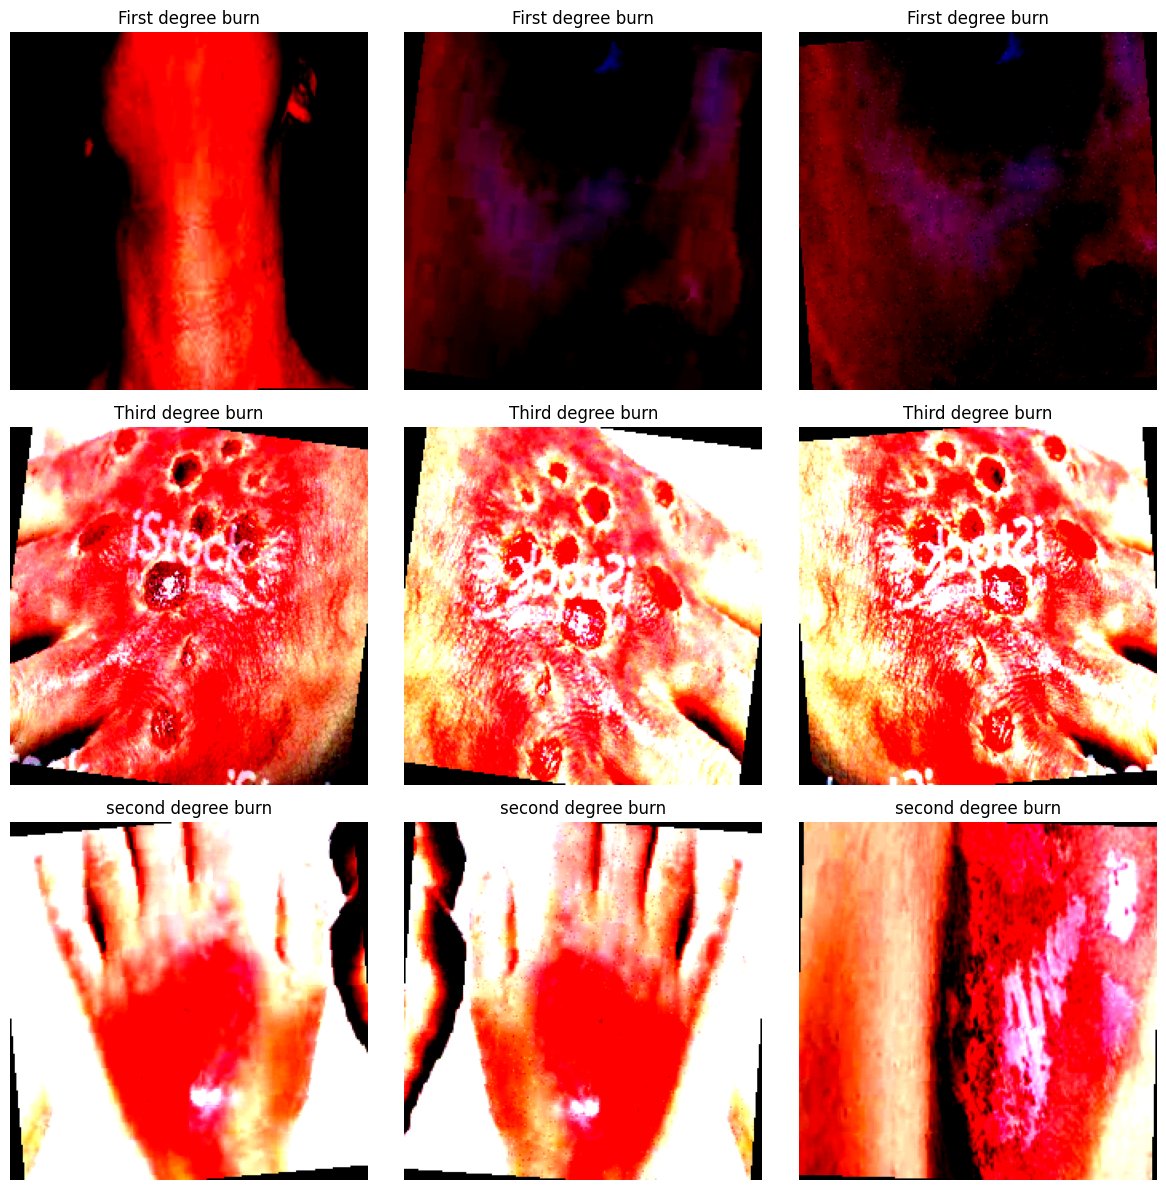

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

count = [0, 0, 0]  # Number of images shown for each class

for img, label in train_dataset:

    if count[label] < 3:
        axes[label, count[label]].imshow(img.permute(1, 2, 0))
        axes[label, count[label]].set_title(train_dataset.classes[label])
        axes[label, count[label]].axis("off")

        count[label] += 1

    # Stop once we've shown 3 images from each class
    if count == [3, 3, 3]:
        break

plt.tight_layout()
plt.show()



# **Load a Pretrained Model**

In [ ]:
num_labels = 3

#Load pretrained model set
model = models.resnet50(pretrained=True).to(device)

#Print the layers to experiment on which layers to shut down
print(model.parameters)
#Freeze training all pretrained weights except last layer (most specific features)
for param in model.parameters():
    param.requires_grad = False

for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

#Classification Layer
model.fc = nn.Sequential(
               nn.Linear(2048, 128),
               nn.ReLU(inplace=True),
               nn.Linear(128, num_labels)).to(device)



The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


<bound method Module.parameters of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 2

# **Begin Training**

In [ ]:
def train_model(model, criterion, optimizer, num_epochs):
  for epoch in range(num_epochs):
      print('Epoch {}/{}'.format(epoch+1, num_epochs))
      print('-' * 10)
      for phase in ["train", "validation"]:

          if phase == "train":
              model.train()
              dataloader = train_loader
          else:
              model.eval()
              dataloader = valid_loader

          running_loss = 0.0
          running_correct = 0

          for inputs, labels in dataloader:
              inputs = inputs.to(device)
              labels = labels.to(device)

              optimizer.zero_grad()

              with torch.set_grad_enabled(phase == "train"):
                  outputs = model(inputs)
                  loss = criterion(outputs, labels)

                  _, preds = torch.max(outputs, 1)

                  if phase == "train":
                      loss.backward()
                      optimizer.step()

              running_loss += loss.item() * inputs.size(0)
              running_correct += torch.sum(preds == labels)

          epoch_loss = running_loss / len(dataloader.dataset)
          epoch_acc = running_correct.double() / len(dataloader.dataset)

          print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
  return model



In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

model_trained = train_model(model, criterion, optimizer, num_epochs=15)

Epoch 1/15
----------
train Loss: 1.0041 Acc: 0.6027
validation Loss: 0.9044 Acc: 0.7121
Epoch 2/15
----------
train Loss: 0.7281 Acc: 0.7680
validation Loss: 0.6391 Acc: 0.7833
Epoch 3/15
----------
train Loss: 0.5164 Acc: 0.8166
validation Loss: 0.5046 Acc: 0.8080
Epoch 4/15
----------
train Loss: 0.3984 Acc: 0.8682
validation Loss: 0.4246 Acc: 0.8483
Epoch 5/15
----------
train Loss: 0.3259 Acc: 0.8863
validation Loss: 0.3917 Acc: 0.8638
Epoch 6/15
----------
train Loss: 0.2628 Acc: 0.9106
validation Loss: 0.3613 Acc: 0.8824
Epoch 7/15
----------
train Loss: 0.2289 Acc: 0.9252
validation Loss: 0.3498 Acc: 0.8947
Epoch 8/15
----------
train Loss: 0.1993 Acc: 0.9329
validation Loss: 0.3238 Acc: 0.9071
Epoch 9/15
----------
train Loss: 0.1704 Acc: 0.9461
validation Loss: 0.3345 Acc: 0.8916
Epoch 10/15
----------
train Loss: 0.1494 Acc: 0.9514
validation Loss: 0.3092 Acc: 0.9009
Epoch 11/15
----------
train Loss: 0.1247 Acc: 0.9595
validation Loss: 0.3104 Acc: 0.8947
Epoch 12/15
-------

# **Evaluate Performance**

In [ ]:
def evaluate_model(model, test_loader, device):
  model.eval()
  y_true = []
  y_pred = []
  start = time.time()
  total_images = 0
  #Make predictions and compare outputs only (NO LEARNING)
  with torch.no_grad():
    for image, labels in test_loader:
      image = image.to(device)
      labels = labels.to(device)

      #Make predictions
      output = model(image)
      preds = output.argmax(dim=1)

      #add predictions and true values to list
      y_true.extend(labels.cpu().numpy())
      y_pred.extend(preds.cpu().numpy())
      total_images += images.size(0)


  #Compute all evaluation metrics
  elapsed = time.time()-start
  time_per_image = elapsed / total_images
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred, average="weighted")
  recall = recall_score(y_true, y_pred, average="weighted")
  f1 = f1_score(y_true, y_pred, average="weighted")

  #Output all results
  print(f"Accuracy : {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall   : {recall:.4f}")
  print(f"F1 Score : {f1:.4f}")
  print(f"Inference Time: {elapsed:.2f} sec")
  print(f"Average Time/Image   : {time_per_image*1000:.2f} ms")

  print("\nConfusion Matrix")
  print(confusion_matrix(y_true, y_pred))

  print("\nClassification Report")
  print(classification_report(y_true, y_pred))

  return accuracy, precision, recall, f1, elapsed, y_true, y_pred

# **Plot Confusion Matrix**

In [ ]:
print("\nRESNET50")
RESNET50_results = evaluate_model(model, test_loader, device)


RESNET50
Accuracy : 0.9385
Precision: 0.9406
Recall   : 0.9385
F1 Score : 0.9388
Inference Time: 2.67 sec
Average Time/Image   : 6.96 ms

Confusion Matrix
[[102   2   6]
 [  0 100   7]
 [  2   3 103]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       110
           1       0.95      0.93      0.94       107
           2       0.89      0.95      0.92       108

    accuracy                           0.94       325
   macro avg       0.94      0.94      0.94       325
weighted avg       0.94      0.94      0.94       325



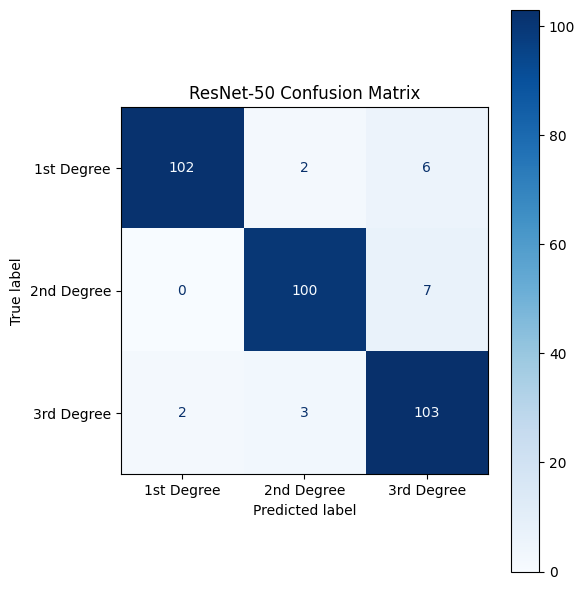

In [ ]:
accuracy, precision, recall, f1, elapsed, y_true, y_pred = RESNET50_results
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "1st Degree",
        "2nd Degree",
        "3rd Degree"
    ]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=True)

plt.title("ResNet-50 Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
torch.save(model_trained.state_dict(), 'BurnClassifierFinal.pth')